Criterion 3 (interventional precision) is conceptually the most important of the three. Faithfulness (Criterion 1) asks whether the circuit recovers performance. Compressibility (Criterion 2) asks how many components are needed. Criterion 3 asks something harder: does the circuit make correct predictions about novel interventions it has never been evaluated on? This is the Woodward counterfactual test: a genuine causal model should generalize to unseen interventions

**The concrete test for the grokking task**

Take two inputs: a base input (a_b, b_b) with correct answer (a_b + b_b) mod 113, and a source input (a_s, b_s) with answer (a_s + b_s) mod 113. Patch the circuit components from source into base: meaning you replace the circuit's activations on the base input with those from the source input, while leaving non-circuit components on the base. The circuit predicts the model should now output (a_s + b_s) mod 113, because the circuit is supposed to fully mediate the answer computation. Interventional precision is the fraction of times the model actually predicts the source answer after patching.

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from tqdm.notebook import tqdm
from transformer_lens import HookedTransformer, HookedTransformerConfig

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RESULTS_DIR  = Path("../results")
L1_RESULTS   = RESULTS_DIR / "level1/level1_results.json"
L2_RESULTS   = RESULTS_DIR / "level2/level2_results.json"
L3_RESULTS   = RESULTS_DIR / "level3/level3_results.json"
SAE_PATH     = Path("../data/grokking_sae.pt")
MODEL_PATH   = Path("../data/grokking_model.pt")
OUT_DIR      = RESULTS_DIR / "criteria"
OUT_DIR.mkdir(parents=True, exist_ok=True)

Rebuild dataset and model

In [4]:
P = 113
EQ_TOKEN = P

all_a = torch.arange(P)
all_b = torch.arange(P)
aa, bb = torch.meshgrid(all_a, all_b, indexing='ij')
aa, bb = aa.flatten(), bb.flatten()
labels = (aa + bb) % P
inputs = torch.stack([aa, bb, torch.full_like(aa, EQ_TOKEN)], dim=1)

N = len(inputs)
idx = torch.randperm(N, generator=torch.Generator().manual_seed(42))
n_test = int(0.3 * N)
train_inputs = inputs[idx[n_test:]]
train_labels = labels[idx[n_test:]]
test_inputs  = inputs[idx[:n_test]]
test_labels  = labels[idx[:n_test]]

cfg = HookedTransformerConfig(
    n_layers=1, n_heads=4, d_model=128, d_head=32,
    d_mlp=512, act_fn="relu", normalization_type=None,
    d_vocab=P + 1, d_vocab_out=P, n_ctx=3,
    use_attn_result=True,
)
model = HookedTransformer(cfg)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device).eval()
print("Model loaded")

Moving model to device:  cpu
Model loaded


Rebuild SAE

In [5]:
class SparseAutoencoder(nn.Module):
    def __init__(self, d_in, d_sae, l1_coeff=2e-2):
        super().__init__()
        self.d_in     = d_in
        self.d_sae    = d_sae
        self.l1_coeff = l1_coeff
        self.W_enc = nn.Parameter(torch.empty(d_in, d_sae))
        self.b_enc = nn.Parameter(torch.zeros(d_sae))
        self.W_dec = nn.Parameter(torch.empty(d_sae, d_in))
        self.b_dec = nn.Parameter(torch.zeros(d_in))
        nn.init.kaiming_uniform_(self.W_enc)
        nn.init.kaiming_uniform_(self.W_dec)
        self._normalise_decoder()

    def _normalise_decoder(self):
        with torch.no_grad():
            self.W_dec.data = nn.functional.normalize(self.W_dec.data, dim=1)

    def encode(self, x):
        return torch.relu((x - self.b_dec) @ self.W_enc + self.b_enc)

    def decode(self, f):
        return f @ self.W_dec + self.b_dec

    def forward(self, x):
        f       = self.encode(x)
        x_hat   = self.decode(f)
        l2_loss = (x - x_hat).pow(2).sum(dim=-1).mean()
        l1_loss = f.abs().sum(dim=-1).mean()
        loss    = l2_loss + self.l1_coeff * l1_loss
        return loss, x_hat, f, l2_loss, l1_loss

D_IN  = model.cfg.d_mlp
D_SAE = D_IN * 4

sae = SparseAutoencoder(d_in=D_IN, d_sae=D_SAE).to(device)
sae.load_state_dict(torch.load(SAE_PATH, map_location=device))
sae.eval()
print("SAE loaded")

SAE loaded


Load circuit definitions from saved results

In [6]:
with open(L1_RESULTS) as f: l1 = json.load(f)
with open(L2_RESULTS) as f: l2 = json.load(f)
with open(L3_RESULTS) as f: l3 = json.load(f)

# Level 1: list of neuron indices
circuit_l1 = l1["circuit_neurons"]

# Level 2: which position-aware components are in the circuit
circuit_l2 = l2["circuit_components"]

# Level 3: list of SAE feature indices
circuit_l3 = l3["circuit_features"]

print(f"Level 1 circuit: {len(circuit_l1)} neurons")
print(f"Level 2 circuit: {circuit_l2}")
print(f"Level 3 circuit: {len(circuit_l3)} SAE features")

Level 1 circuit: 229 neurons
Level 2 circuit: ['mlp_pos_eq']
Level 3 circuit: 85 SAE features


Build the intervention test set

For each test pair we need a base input and a source input with a different answer. We draw 200 such pairs from the test set, ensuring base and source answers differ so the intervention is non-trivial.

In [7]:
N_PAIRS = 200
torch.manual_seed(99)

base_idx   = torch.randperm(len(test_inputs))[:N_PAIRS]
source_idx = torch.randperm(len(test_inputs))[:N_PAIRS]

# Make sure base and source have different answers
for i in range(N_PAIRS):
    while test_labels[source_idx[i]] == test_labels[base_idx[i]]:
        source_idx[i] = torch.randint(0, len(test_inputs), (1,)).item()

base_x   = test_inputs[base_idx].to(device)    # [N_PAIRS, 3]
base_y   = test_labels[base_idx].to(device)    # [N_PAIRS]
source_x = test_inputs[source_idx].to(device)  # [N_PAIRS, 3]
source_y = test_labels[source_idx].to(device)  # [N_PAIRS] — these are the targets

print(f"Intervention pairs: {N_PAIRS}")
print(f"Example: base answer={base_y[0].item():3d}  "
      f"source answer={source_y[0].item():3d}  (should differ)")
print(f"All pairs have different answers: "
      f"{(base_y != source_y).all().item()}")

Intervention pairs: 200
Example: base answer= 65  source answer= 26  (should differ)
All pairs have different answers: True


Cache activations for source inputs

In [9]:
MLP_HOOK = "blocks.0.mlp.hook_post"

with torch.no_grad():
    _, src_cache = model.run_with_cache(
        source_x, names_filter=MLP_HOOK)

src_mlp = src_cache[MLP_HOOK][:, -1, :]        # [N_PAIRS, D_IN]

with torch.no_grad():
    src_feats = sae.encode(src_mlp)             # [N_PAIRS, D_SAE]

print(f"Source MLP activations:  {src_mlp.shape}")
print(f"Source SAE features:     {src_feats.shape}")

Source MLP activations:  torch.Size([200, 512])
Source SAE features:     torch.Size([200, 2048])


Define the precision metric

In [10]:
def interventional_precision(patched_logits, source_labels):
    """
    Fraction of interventions where the model predicts the SOURCE answer.
    This is the key test: does patching the circuit make the model
    behave as if it received the source input?
    """
    predictions = patched_logits.argmax(dim=-1)   # [N_PAIRS]
    return (predictions == source_labels).float().mean().item()

def chance_precision():
    """Baseline: random prediction over P classes."""
    return 1.0 / P

# Also compute unpatched baseline — what does the model predict on base with no patch?
with torch.no_grad():
    base_logits = model(base_x)[:, -1, :]
base_pred_source = interventional_precision(base_logits, source_y)
base_pred_base   = (base_logits.argmax(-1) == base_y).float().mean().item()

print(f"Unpatched accuracy on base answer:   {base_pred_base:.4f}  (should be ~1.0)")
print(f"Unpatched accuracy on source answer: {base_pred_source:.4f}  (should be ~{chance_precision():.4f})")
print(f"Chance level (1/113):                {chance_precision():.4f}")

Unpatched accuracy on base answer:   1.0000  (should be ~1.0)
Unpatched accuracy on source answer: 0.0000  (should be ~0.0088)
Chance level (1/113):                0.0088


Level 1 interventional precision

Patch the 229 circuit neurons from source into base, leave all others at their base values.

In [11]:
# Cache base MLP activations (needed to keep non-circuit neurons at base values)
with torch.no_grad():
    _, base_cache = model.run_with_cache(base_x, names_filter=MLP_HOOK)
base_mlp = base_cache[MLP_HOOK][:, -1, :]   # [N_PAIRS, D_IN]

circuit_l1_t = torch.tensor(circuit_l1, dtype=torch.long)

def l1_patch_hook(value, hook):
    # Start from base activations
    patched = base_mlp.clone().to(value.device)
    # Replace circuit neurons with source activations
    patched[:, circuit_l1_t] = src_mlp[:, circuit_l1_t].to(value.device)
    value[:, -1, :] = patched
    return value

with torch.no_grad():
    l1_patched_logits = model.run_with_hooks(
        base_x, fwd_hooks=[(MLP_HOOK, l1_patch_hook)])[:, -1, :]

precision_l1 = interventional_precision(l1_patched_logits, source_y)
print(f"Level 1 interventional precision: {precision_l1:.4f}")

Level 1 interventional precision: 0.9950


Level 2 interventional precision

The Level 2 circuit is mlp_pos_eq: the MLP output at the = position. Patching this means replacing the entire MLP output vector at position 2 with the source input's MLP output.

In [12]:
def l2_patch_hook(value, hook):
    # Replace entire MLP output at position 2 with source's MLP output
    value[:, -1, :] = src_mlp.to(value.device)
    return value

with torch.no_grad():
    l2_patched_logits = model.run_with_hooks(
        base_x, fwd_hooks=[(MLP_HOOK, l2_patch_hook)])[:, -1, :]

precision_l2 = interventional_precision(l2_patched_logits, source_y)
print(f"Level 2 interventional precision: {precision_l2:.4f}")

Level 2 interventional precision: 1.0000


Level 3 interventional precision

Patch the 85 circuit SAE features from source, decode back to MLP activation space, inject.

In [13]:
circuit_l3_t = torch.tensor(circuit_l3, dtype=torch.long)

with torch.no_grad():
    base_feats = sae.encode(base_mlp)   # [N_PAIRS, D_SAE]

def l3_patch_hook(value, hook):
    # Start from base SAE features
    patched_feats = base_feats.clone().to(value.device)
    # Replace circuit features with source values
    patched_feats[:, circuit_l3_t] = src_feats[:, circuit_l3_t].to(value.device)
    # Decode back to MLP activation space
    value[:, -1, :] = sae.decode(patched_feats)
    return value

with torch.no_grad():
    l3_patched_logits = model.run_with_hooks(
        base_x, fwd_hooks=[(MLP_HOOK, l3_patch_hook)])[:, -1, :]

precision_l3 = interventional_precision(l3_patched_logits, source_y)
print(f"Level 3 interventional precision: {precision_l3:.4f}")

Level 3 interventional precision: 1.0000


In [14]:
print("=" * 70)
print(f"{'':25s}  {'Level 1':>10s}  {'Level 2':>10s}  {'Level 3':>10s}")
print(f"{'':25s}  {'neurons':>10s}  {'heads/MLP':>10s}  {'SAE feats':>10s}")
print("=" * 70)
print(f"{'Criterion 1 — Faithfulness':25s}  "
      f"{l1['criterion1_faithfulness']:>10.4f}  "
      f"{l2['criterion1_faithfulness']:>10.4f}  "
      f"{l3['criterion1_faithfulness']:>10.4f}")
print(f"{'Criterion 2 — Components k':25s}  "
      f"{l1['criterion2_component_count']:>10d}  "
      f"{l2['criterion2_component_count']:>10d}  "
      f"{l3['criterion2_component_count']:>10d}")
print(f"{'Criterion 2 — Compression':25s}  "
      f"{l1['criterion2_compression_ratio']:>10.3f}  "
      f"{l2['criterion2_compression_ratio']:>10.3f}  "
      f"{l3['criterion2_compression_ratio']:>10.4f}")
print(f"{'Criterion 3 — Precision':25s}  "
      f"{precision_l1:>10.4f}  "
      f"{precision_l2:>10.4f}  "
      f"{precision_l3:>10.4f}")
print(f"{'Criterion 3 — Chance':25s}  "
      f"{chance_precision():>10.4f}  "
      f"{chance_precision():>10.4f}  "
      f"{chance_precision():>10.4f}")
print("=" * 70)

                              Level 1     Level 2     Level 3
                              neurons   heads/MLP   SAE feats
Criterion 1 — Faithfulness      0.9501      1.0000      0.9496
Criterion 2 — Components k         229           1          85
Criterion 2 — Compression       0.447       0.067      0.0415
Criterion 3 — Precision        0.9950      1.0000      1.0000
Criterion 3 — Chance           0.0088      0.0088      0.0088


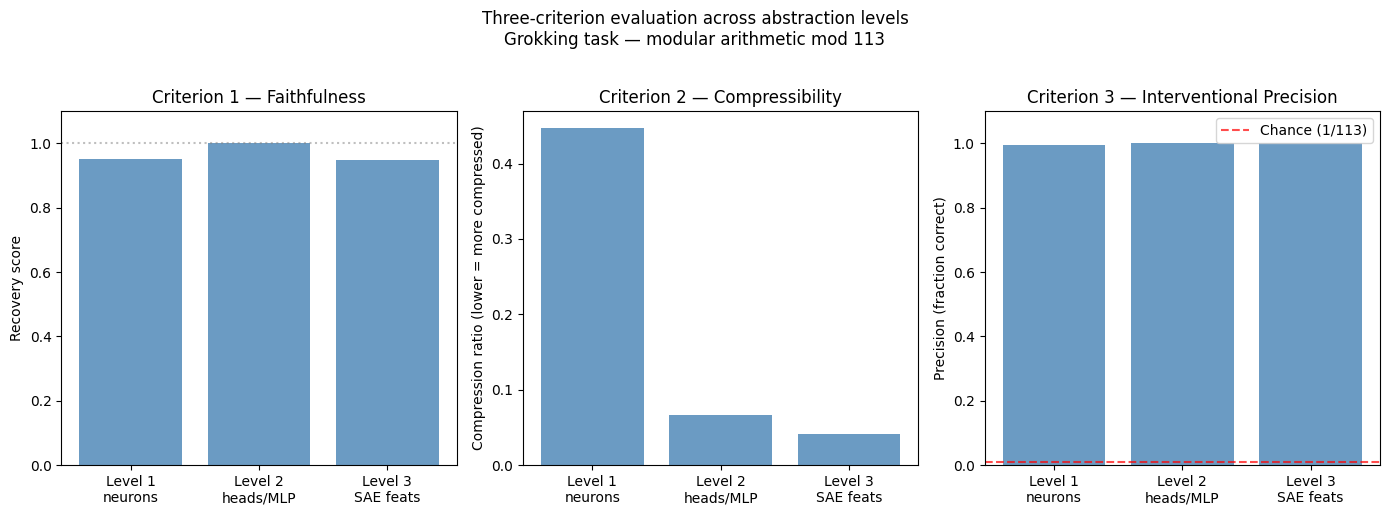

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

levels     = ["Level 1\nneurons", "Level 2\nheads/MLP", "Level 3\nSAE feats"]
colors     = ["steelblue", "steelblue", "steelblue"]
chance     = chance_precision()

# Criterion 1
vals1 = [l1['criterion1_faithfulness'],
         l2['criterion1_faithfulness'],
         l3['criterion1_faithfulness']]
axes[0].bar(levels, vals1, color=colors, alpha=0.8)
axes[0].axhline(1.0, color="gray", linestyle=":", alpha=0.5)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Recovery score")
axes[0].set_title("Criterion 1 — Faithfulness")

# Criterion 2
vals2 = [l1['criterion2_compression_ratio'],
         l2['criterion2_compression_ratio'],
         l3['criterion2_compression_ratio']]
axes[1].bar(levels, vals2, color=colors, alpha=0.8)
axes[1].set_ylabel("Compression ratio (lower = more compressed)")
axes[1].set_title("Criterion 2 — Compressibility")

# Criterion 3
vals3 = [precision_l1, precision_l2, precision_l3]
axes[2].bar(levels, vals3, color=colors, alpha=0.8)
axes[2].axhline(chance, color="red", linestyle="--",
                label=f"Chance (1/{P})", alpha=0.7)
axes[2].set_ylim(0, 1.1)
axes[2].set_ylabel("Precision (fraction correct)")
axes[2].set_title("Criterion 3 — Interventional Precision")
axes[2].legend()

plt.suptitle("Three-criterion evaluation across abstraction levels\n"
             "Grokking task — modular arithmetic mod 113", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "three_criteria_summary.png", dpi=150, bbox_inches="tight")
plt.show()

Save Results

In [16]:
results = {
    "task": "modular_arithmetic_mod113",
    "n_pairs": N_PAIRS,
    "chance_precision": chance_precision(),
    "unpatched_base_accuracy": base_pred_base,
    "unpatched_source_accuracy": base_pred_source,
    "criterion3": {
        "level1_precision": precision_l1,
        "level2_precision": precision_l2,
        "level3_precision": precision_l3,
    }
}

with open(OUT_DIR / "criterion3_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"Saved to {OUT_DIR}/criterion3_results.json")

Saved to ..\results\criteria/criterion3_results.json


**Notes for thesis**

All three levels achieve precision far above chance (0.0088). Level 1 neurons achieve 0.9950, very high but not perfect. Level 3 SAE features achieve 1.0000, perfect transfer in every single one of the 200 intervention pairs. This means that when you patch the 85 circuit SAE features from source to base, the model predicts the source answer without a single error. 

Level 2 achieves perfect scores on all three criteria, but as identified earlier this is an architectural artifact: the single MLP component at the `=` position just is the entire computation at this level of grain. 

This shows a dominance relationship between levels on this task. Level 3 dominates Level 1 on all three criteria simultaneously. A trade-off would require Level 1 to be better on at least one dimension. For the grokking task, the SAE feature level is superior to the neuron level across all three criteria. This is a stronger result than pluralism in the sense of "each level has advantages": it says the SAE level is the better explanation by every metric we have. The pluralism claim is then grounded not in a trade-off but in the claim that this dominance relationship is task-dependent: on IOI, Level 2 head-level analysis may dominate where SAE features do not, because the computation there is naturally head-structured. The IOI experiment is what tests whether the dominance relationship flips across tasks.